<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Willy-Projet/Modele_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=7961939d-0aa7-405c-811c-7c70e3f65cd9
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 51.8MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [8]:
import os
import shutil
from pathlib import Path

# =====================================
# CHEMINS
# =====================================
src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# =====================================
# NETTOYAGE SI LE DOSSIER EXISTE DEJA
# =====================================
if dst_root.exists():
    shutil.rmtree(dst_root)

# =====================================
# CREATION DES DOSSIERS DE DESTINATION
# =====================================
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================
# FONCTION DE COPIE SECURISEE
# =====================================
def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name
    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"
    shutil.copy2(src_file, dst_file)

# =====================================
# FUSION DES CLASSES EN BINAIRE
# =====================================
for split in splits:
    # Fusion des classes tumor
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor
    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

# =====================================
# VERIFICATION
# =====================================
print("✅ Fusion binaire terminée.")
print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))
print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [9]:
import tensorflow as tf
import os

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = "/content/Binary/Training"
test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

# ==============================
# CHARGEMENT DU DATASET TRAIN
# ==============================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

# ==============================
# CHARGEMENT DU DATASET TEST
# ==============================
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [10]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [11]:
# Equilibrer le data  d entrainement
import shutil
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================
# DOSSIERS SOURCE
# =====================================
train_no = Path("/content/Binary/Training/no_tumor")
train_tu = Path("/content/Binary/Training/tumor")

# =====================================
# DOSSIERS DESTINATION EQUILIBRES
# =====================================
balanced_root = Path("/content/Binary/Training_balanced")
balanced_no = balanced_root / "no_tumor"
balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà
if balanced_root.exists():
    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)
balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================
# LISTE DES IMAGES
# =====================================
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)
print("Nombre initial tumor    :", n_tu)

# =====================================
# COPIE DES IMAGES ORIGINALES
# =====================================
for f in no_files:
    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:
    shutil.copy2(f, balanced_tu / f.name)

# =====================================
# DATA AUGMENTATION
# =====================================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# =====================================
# FONCTION POUR GENERER JUSQU'A EQUILIBRE
# =====================================
def augment_until_target(files, output_dir, target_count, prefix):
    current_count = len(list(output_dir.glob("*")))
    i = 0

    while current_count < target_count:
        img_path = files[i % len(files)]
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")
        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"
        save_img(save_path, aug_img)

        current_count += 1
        i += 1

# =====================================
# EQUILIBRAGE
# =====================================
target = max(n_no, n_tu)

if n_no < target:
    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:
    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")
print("no_tumor final :", len(list(balanced_no.glob('*'))))
print("tumor final    :", len(list(balanced_tu.glob('*'))))

Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [12]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['tumor', 'no_tumor']
Classes test            : ['tumor', 'no_tumor']


In [13]:
# Créer train et validation à partir du train équilibré
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Noms des classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


In [14]:
# Normalisation
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# COUCHE DE NORMALISATION
# ==============================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==============================
# APPLICATION SUR LES DATASETS
# ==============================
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# ==============================
# OPTIMISATION DU PIPELINE
# ==============================
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Normalisation terminée (pixels entre 0 et 1)")

✅ Normalisation terminée (pixels entre 0 et 1)


/tmp/ipykernel_1207/2786853809.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


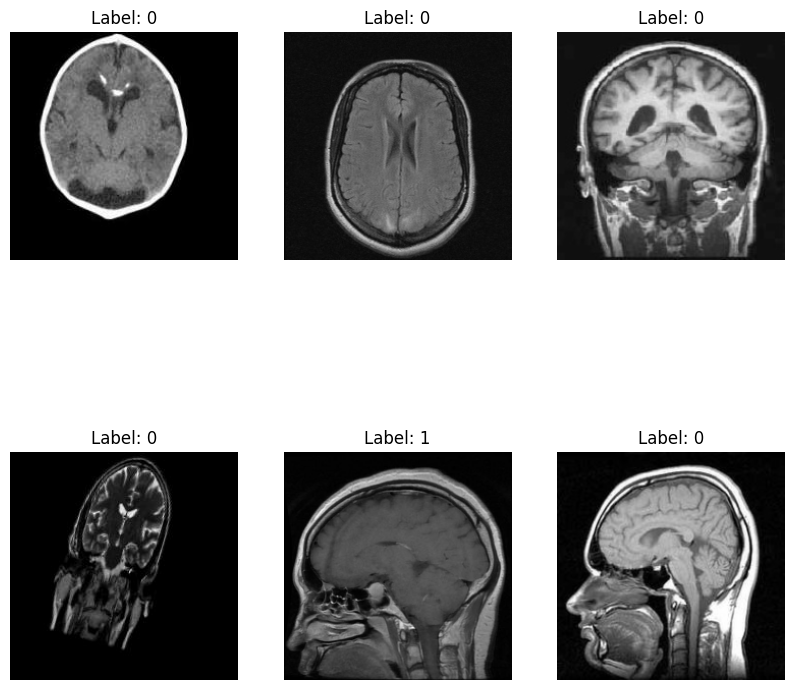

In [15]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()

## Modele  DenseNet121

In [16]:
# Nettoyer la memoire
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()

0

In [17]:
# recharger les dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes :", train_ds.class_names)

# Sauvegarder les classes (important)
class_names = train_ds.class_names

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [18]:
# Optimiser le pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [19]:
# Modele DenseNet121
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base DenseNet
base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,172,929 (27.36 MB)

 Trainable params: 133,377 (521.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [20]:
# compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("/content/densenet_best.keras", save_best_only=True)
]

In [22]:
#Entraînement avec class_weight
class_weight = {
    0: 1.0,
    1: 1.5
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 258ms/step - accuracy: 0.8288 - loss: 0.4661 - val_accuracy: 0.9111 - val_loss: 0.2391 - learning_rate: 1.0000e-04
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 27s 195ms/step - accuracy: 0.9240 - loss: 0.2437 - val_accuracy: 0.9384 - val_loss: 0.1722 - learning_rate: 1.0000e-04
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 203ms/step - accuracy: 0.9404 - loss: 0.1968 - val_accuracy: 0.9535 - val_loss: 0.1390 - learning_rate: 1.0000e-04
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.9510 - loss: 0.1684 - val_accuracy: 0.9535 - val_loss: 0.1202 - learning_rate: 1.0000e-04
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 197ms/step - accuracy: 0.9556 - loss: 0.1523 - val_accuracy: 0.9616 - val_loss: 0.1039 - learning_rate: 1.0000e-04
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.9654 - loss: 0.1395 - val_accuracy: 0.9626 - val_loss: 0.0960 - learning_rate: 1.0000e-04
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 20

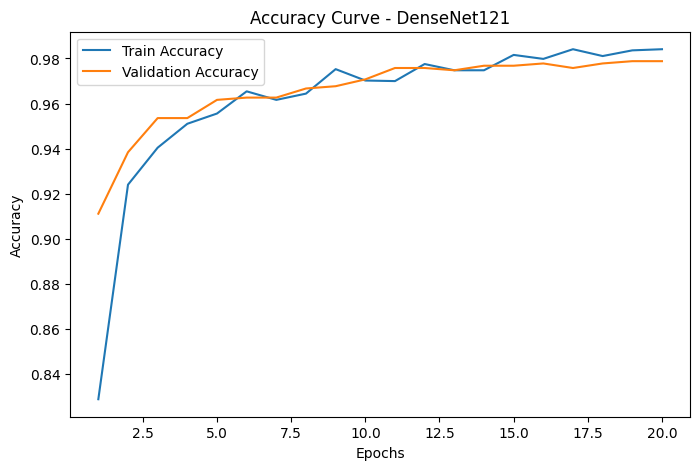

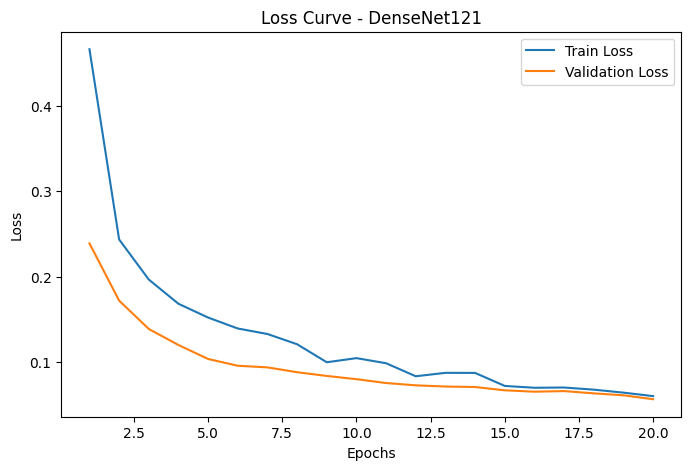

In [23]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# ==============================
# ACCURACY
# ==============================
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve - DenseNet121")
plt.legend()
plt.show()

# ==============================
# LOSS
# ==============================
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - DenseNet121")
plt.legend()
plt.show()

In [24]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy DenseNet121 : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.8883 - loss: 0.3005
Test Accuracy DenseNet121 : 0.8883


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 479ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9766536964980544
Recall tumor    : 0.8685121107266436
F1-score tumor  : 0.9194139194139194
Matrice de confusion :
[[ 99   6]
 [ 38 251]]

===== Seuil = 0.4 =====
Precision tumor : 0.9625468164794008
Recall tumor    : 0.889273356401384
F1-score tumor  : 0.9244604316546763
Matrice de confusion :
[[ 95  10]
 [ 32 257]]

===== Seuil = 0.3 =====
Precision tumor : 0.9359430604982206
Recall tumor    : 0.9100346020761245
F1-score tumor  : 0.9228070175438596
Matrice de confusion :
[[ 87  18]
 [ 26 263]]

===== Seuil = 0.2 =====
Precision tumor : 0.9163879598662207
Recall tumor    : 0.9480968858131488
F1-score tumor  : 0.9319727891156463
Matrice de confusion :
[[ 80  25]
 [ 15 274]]

✅ Meilleur seuil choisi : 0.2

📊 Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.84      0.76      0.80       105
       tumor       0.92      0.95      0.93       289

    

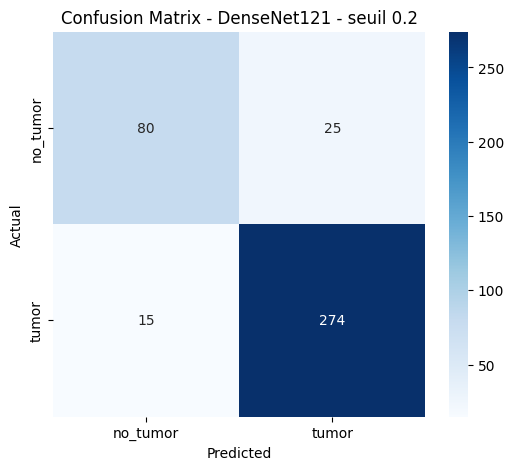

In [25]:
# Optimisation du seuil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# ==============================
# VRAIES ETIQUETTES + PROBABILITES
# ==============================
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

# ==============================
# TEST DE PLUSIEURS SEUILS
# ==============================
thresholds = [0.5, 0.4, 0.3, 0.2]
results = []

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")
    print("Precision tumor :", precision)
    print("Recall tumor    :", recall)
    print("F1-score tumor  :", f1)
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))

# ==============================
# CHOIX DU MEILLEUR SEUIL
# ==============================
best_threshold = max(results, key=lambda x: x[2])[0]  # basé sur F1-score
print("\n✅ Meilleur seuil choisi :", best_threshold)

# ==============================
# RESULTAT FINAL
# ==============================
y_pred_best = (y_prob > best_threshold).astype(int)

print("\n📊 Classification Report final :")
print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - DenseNet121 - seuil {best_threshold}")
plt.show()

Le modèle DenseNet121, avec un seuil de 0.2, atteint une accuracy d’environ 87% et un rappel élevé de 0.93 pour la classe tumor, ce qui indique une très bonne capacité à détecter les tumeurs. Le nombre de faux négatifs est réduit à 19, ce qui améliore la sécurité du modèle en contexte médical. Malgré une légère augmentation des faux positifs, ce compromis est acceptable car il privilégie la détection des cas critiques.